# Bike Share Demand — Model Training

Predict hourly departures per station so ops can rebalance bikes before stations run dry.
Regression at the **station-hour** grain.

**Data** (produced by the Spark pipeline, see `spark/notebooks/split.ipynb`) — chronological split:

| split | source | period | rows |
|---|---|---|---|
| train | `data/featured/train/` | 2019–2022 | 51.4M |
| test  | `data/featured/test/`  | 2023      | 12.9M |

We read the **partitioned Parquet**, not the exported CSVs — it is ~117 MB on disk vs 7.2 GB,
and supports column/predicate pushdown.

**Business problem:** `docs/ml/01-problem.md`

---

### Three known data defects, handled below

| # | Defect | Handling |
|---|---|---|
| 1 | Duplicate `(station_id, start_date, hour)` rows with conflicting `lag_1h` | dedupe on read (Step 3) |
| 2 | `member_ratio` is **target leakage** — computed from the same hour's trips, and null exactly when `trip_count == 0` | drop from features |
| 3 | `is_holiday` only populated for 2019–2020 (hard-coded list in `ml-ds.ipynb` stops at 2020) so train/test disagree on its meaning | drop from features |

Defects 1 and 3 are upstream bugs; fixing them at source means re-materializing 64M rows,
so they are worked around here. See the plan's *Deferred* section.

## Step 1 — Environment

Install dependencies from a terminal, then restart the kernel.

```bash
cd ml
pip install --only-binary=:all: -r requirements.txt
```

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
N_STATIONS = 150          # busiest stations to keep; full data won't fit in pandas
VALIDATION_YEAR = 2022    # held out of train for tuning; test (2023) stays untouched

# Notebook lives in ml/, data lives at the repo root.
ROOT = Path.cwd().parent if Path.cwd().name == "ml" else Path.cwd()
FEATURED = ROOT / "data" / "featured"
TRAIN_DIR, TEST_DIR = FEATURED / "train", FEATURED / "test"
ARTIFACTS = ROOT / "ml" / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

for d in (TRAIN_DIR, TEST_DIR):
    assert d.exists(), f"missing {d} — run spark/notebooks/split.ipynb first"

print(f"root      {ROOT}")
print(f"train     {TRAIN_DIR}")
print(f"test      {TEST_DIR}")
print(f"artifacts {ARTIFACTS}")

root      c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike
train     c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\data\featured\train
test      c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\data\featured\test
artifacts c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\ml\artifacts


## Step 2 — Load from Parquet

51M rows will not fit in pandas, so we keep **every hour for the busiest `N_STATIONS`**
rather than randomly sampling rows. Random sampling would shred the lag/rolling structure
and over-represent the ~79% zero rows; a station subset keeps each station's hourly series
intact, which is what a demand model needs.

Two passes:
1. Read only `station_id` + `trip_count` to rank stations by total volume.
2. Re-read both splits filtered to that subset, with column pushdown.

In [2]:
# Pass 1 — rank stations by total volume (reads 2 columns only).
train_ds = ds.dataset(TRAIN_DIR, format="parquet", partitioning="hive")
test_ds = ds.dataset(TEST_DIR, format="parquet", partitioning="hive")

print("parquet schema:")
print(train_ds.schema.to_string(show_field_metadata=False))

volume = (
    train_ds.to_table(columns=["station_id", "trip_count"])
    .to_pandas()
    .groupby("station_id")["trip_count"]
    .sum()
    .sort_values(ascending=False)
)
TOP_STATIONS = volume.head(N_STATIONS).index.tolist()

share = volume.head(N_STATIONS).sum() / volume.sum()
print(f"\n{len(volume):,} stations total; keeping top {N_STATIONS}")
print(f"they carry {share:.1%} of all training trips")

parquet schema:
station_id: int32
start_date: date32[day]
hour: int32
trip_count: int64
quarter: int32
day_of_week: int32
is_weekend: int32
is_holiday: int32
hour_sin: double
hour_cos: double
dow_sin: double
dow_cos: double
lag_1h: int64
lag_24h: int64
lag_168h: int64
roll_mean_24h: double
roll_mean_168h: double
member_ratio: double
year: int32
month: int32
-- schema metadata --
org.apache.spark.version: '3.5.0'
org.apache.spark.sql.parquet.row.metadata: '{"type":"struct","fields":[{"' + 1201

856 stations total; keeping top 150
they carry 56.6% of all training trips


In [3]:
# Pass 2 — load both splits, filtered to the station subset.
# `year` is a hive partition key (from the directory path), not a file column.
READ_COLUMNS = [
    "station_id", "start_date", "hour", "trip_count", "year",
    "quarter", "day_of_week", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "lag_1h", "lag_24h", "lag_168h", "roll_mean_24h", "roll_mean_168h",
]

station_filter = ds.field("station_id").isin(TOP_STATIONS)


def load(dataset, name):
    df = dataset.to_table(columns=READ_COLUMNS, filter=station_filter).to_pandas()
    mem = df.memory_usage(deep=True).sum() / 1024**3
    print(f"{name:6} {len(df):>10,} rows  {mem:5.2f} GB")
    return df


train_raw = load(train_ds, "train")
test_raw = load(test_ds, "test")

train  10,494,000 rows   1.41 GB
test    2,628,000 rows   0.35 GB


## Step 3 — Clean

The grain is supposed to be one row per `(station_id, start_date, hour)`, but the upstream
join fans out: **every row appears exactly twice** (verified — 50.0% duplication over a
3M-row scan). `trip_count` always agrees between copies; `lag_1h` differs in ~51% of pairs.

Which copy is right? Reconstructing the true previous-hour `trip_count` and comparing:

| rule | correct |
|---|---|
| **keep first copy** | **100.0%** |
| keep second copy | 0.0% |
| keep larger `lag_1h` | 49.4% |
| keep smaller `lag_1h` | 50.6% |

So `keep="first"` recovers the correct lag exactly, while any value-based heuristic is a
coin flip. Parquet row order is deterministic, so this is stable across runs.

We then drop the two unusable columns and assert the split is genuinely chronological.

In [4]:
GRAIN = ["station_id", "start_date", "hour"]


def clean(df, name):
    before = len(df)
    df = df.drop_duplicates(subset=GRAIN, keep="first").copy()
    dropped = before - len(df)
    print(f"{name:6} {before:>10,} -> {len(df):>10,}  ({dropped:,} dupes, {dropped/before:.1%})")

    df["start_date"] = pd.to_datetime(df["start_date"])
    df["station_id"] = df["station_id"].astype("category")
    return df.sort_values(GRAIN).reset_index(drop=True)


train = clean(train_raw, "train")
test = clean(test_raw, "test")

# Test stations must be a subset of train's, or the categorical encoding breaks.
test["station_id"] = test["station_id"].cat.set_categories(train["station_id"].cat.categories)
assert not test["station_id"].isna().any(), "test contains stations unseen in train"

del train_raw, test_raw

train  10,494,000 ->  5,247,000  (5,247,000 dupes, 50.0%)
test    2,628,000 ->  1,314,000  (1,314,000 dupes, 50.0%)


In [5]:
# Leakage guards — these must hold before any model sees the data.
assert train["start_date"].max() < test["start_date"].min(), "train/test dates overlap"
assert not train.duplicated(subset=GRAIN).any(), "train still has duplicate station-hours"
assert not test.duplicated(subset=GRAIN).any(), "test still has duplicate station-hours"

print(f"train  {train['start_date'].min():%Y-%m-%d} .. {train['start_date'].max():%Y-%m-%d}")
print(f"test   {test['start_date'].min():%Y-%m-%d} .. {test['start_date'].max():%Y-%m-%d}")
print()
print(f"train  mean={train['trip_count'].mean():.3f}  "
      f"zero_share={(train['trip_count'] == 0).mean():.1%}  max={train['trip_count'].max()}")
print(f"test   mean={test['trip_count'].mean():.3f}  "
      f"zero_share={(test['trip_count'] == 0).mean():.1%}  max={test['trip_count'].max()}")

train  2019-01-04 .. 2022-12-31
test   2023-01-01 .. 2023-12-31

train  mean=1.984  zero_share=55.1%  max=170
test   mean=2.075  zero_share=44.4%  max=112


## Step 4 — Feature set

**Excluded on purpose:**

- `member_ratio` — leakage. Derived from the same hour's trips and null exactly when
  `trip_count == 0`, so its missingness alone reveals the target.
- `is_holiday` — only populated for 2019–2020 (the hard-coded `ONTARIO_HOLIDAYS` list in
  `ml-ds.ipynb` stops at 2020). Train and test therefore disagree on what the flag means.
- `start_date`, `year`, `month` — time index and partition keys, not features. Keeping raw
  `year` would let the model latch onto a trend it cannot extrapolate to 2023.

In [6]:
TARGET = "trip_count"
CATEGORICAL = ["station_id"]
NUMERIC = [
    "hour", "quarter", "day_of_week", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "lag_1h", "lag_24h", "lag_168h", "roll_mean_24h", "roll_mean_168h",
]
FEATURES = CATEGORICAL + NUMERIC

BANNED = {"member_ratio", "is_holiday", "start_date", "year", "month"}
assert not BANNED & set(FEATURES), f"banned column leaked into features: {BANNED & set(FEATURES)}"

# Chronological validation split: fit on 2019-2021, tune on 2022. Never random-split a
# time series. Test (2023) is untouched until the final evaluation.
fit_mask = train["year"] < VALIDATION_YEAR
X_fit, y_fit = train.loc[fit_mask, FEATURES], train.loc[fit_mask, TARGET]
X_val, y_val = train.loc[~fit_mask, FEATURES], train.loc[~fit_mask, TARGET]
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"fit    {len(X_fit):>9,}  (2019-{VALIDATION_YEAR - 1})")
print(f"val    {len(X_val):>9,}  ({VALIDATION_YEAR})")
print(f"train  {len(X_train):>9,}  (full, for the final refit)")
print(f"test   {len(X_test):>9,}  (2023)")
print(f"\n{len(FEATURES)} features: {FEATURES}")

fit    3,933,000  (2019-2021)
val    1,314,000  (2022)
train  5,247,000  (full, for the final refit)
test   1,314,000  (2023)

14 features: ['station_id', 'hour', 'quarter', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_24h', 'lag_168h', 'roll_mean_24h', 'roll_mean_168h']


## Step 5 — Baselines

Computed on the test set **before** any model, so the bar is set honestly.

`lag_168h` (same hour last week) is the one to beat — for hourly demand with strong weekly
seasonality it is a genuinely strong predictor, and a model that cannot clear it is not
worth deploying.

In [7]:
def score(y_true, y_pred, name):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)  # demand is non-negative
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }


results = [
    score(y_test, test["lag_168h"], "baseline: lag_168h (same hour last week)"),
    score(y_test, test["lag_24h"], "baseline: lag_24h (same hour yesterday)"),
    score(y_test, test["lag_1h"], "baseline: lag_1h (previous hour)"),
    score(y_test, test["roll_mean_24h"], "baseline: roll_mean_24h"),
    score(y_test, np.full(len(y_test), y_train.mean()), "baseline: global mean"),
]

BASELINE_MAE = results[0]["MAE"]  # lag_168h — the bar to beat
pd.DataFrame(results).set_index("model").round(4)

,MAE,RMSE,R2
model,,,
baseline: lag_168h (same hour last week),2.9100,4.6743,-1.0930
baseline: lag_24h (same hour yesterday),2.8611,4.6134,-1.0389
baseline: lag_1h (previous hour),1.5043,2.6778,0.3131
baseline: roll_mean_24h,1.8064,2.8508,0.2214
baseline: global mean,2.1756,3.2322,-0.0008


## Step 6 — Models

- **Ridge** — cheap linear reference. Needs scaling and one-hot `station_id`.
- **HistGradientBoostingRegressor** — sklearn's histogram GBM. Fast on millions of rows,
  handles NaN natively, and takes `station_id` as a native categorical (no 150-column
  one-hot blowup).

Both are tuned against the 2022 validation split, then refit on all of 2019–2022.

In [8]:
%%time
ridge = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL),
        ("num", StandardScaler(), NUMERIC),
    ])),
    ("model", Ridge(alpha=1.0)),
])
ridge.fit(X_train, y_train)

results.append(score(y_test, ridge.predict(X_test), "Ridge"))
print(results[-1])

{'model': 'Ridge', 'MAE': 1.3558861872473509, 'RMSE': 2.245142332644111, 'R2': 0.5171270831100716}
CPU times: total: 8.41 s
Wall time: 8.6 s


In [9]:
%%time
# Small chronological grid search: fit on 2019-2021, score on 2022.
GRID = [
    {"learning_rate": 0.1, "max_leaf_nodes": 31, "max_iter": 300},
    {"learning_rate": 0.1, "max_leaf_nodes": 63, "max_iter": 300},
    {"learning_rate": 0.05, "max_leaf_nodes": 63, "max_iter": 500},
]

search = []
for params in GRID:
    m = HistGradientBoostingRegressor(
        categorical_features=CATEGORICAL,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=RANDOM_STATE,
        **params,
    ).fit(X_fit, y_fit)

    mae = mean_absolute_error(y_val, np.clip(m.predict(X_val), 0, None))
    search.append({**params, "val_MAE": mae, "n_iter": m.n_iter_})
    print(f"{params}  val_MAE={mae:.4f}  stopped@{m.n_iter_}")

search_df = pd.DataFrame(search).sort_values("val_MAE")
BEST = {k: search_df.iloc[0][k] for k in ("learning_rate", "max_leaf_nodes", "max_iter")}
BEST = {"learning_rate": float(BEST["learning_rate"]),
        "max_leaf_nodes": int(BEST["max_leaf_nodes"]),
        "max_iter": int(BEST["max_iter"])}
print(f"\nbest: {BEST}")
search_df.round(4)

{'learning_rate': 0.1, 'max_leaf_nodes': 31, 'max_iter': 300}  val_MAE=1.0487  stopped@300
{'learning_rate': 0.1, 'max_leaf_nodes': 63, 'max_iter': 300}  val_MAE=1.0449  stopped@300
{'learning_rate': 0.05, 'max_leaf_nodes': 63, 'max_iter': 500}  val_MAE=1.0458  stopped@500

best: {'learning_rate': 0.1, 'max_leaf_nodes': 63, 'max_iter': 300}
CPU times: total: 24min 40s
Wall time: 3min 30s


,learning_rate,max_leaf_nodes,max_iter,val_MAE,n_iter
1,0.10,63,300,1.0449,300
2,0.05,63,500,1.0458,500
0,0.10,31,300,1.0487,300


In [10]:
%%time
# Final refit on all of 2019-2022 with the winning hyperparameters.
#
# early_stopping is off here: sklearn's internal holdout is drawn *randomly*, which would
# leak future hours into the stopping decision. The grid above already established the
# iteration count against a clean chronological 2022 split, so we simply refit for it.
hgb = HistGradientBoostingRegressor(
    categorical_features=CATEGORICAL,
    early_stopping=False,
    random_state=RANDOM_STATE,
    **BEST,
)
hgb.fit(X_train, y_train)

results.append(score(y_test, hgb.predict(X_test), "HistGradientBoosting"))
print(results[-1])

{'model': 'HistGradientBoosting', 'MAE': 1.1507254329670364, 'RMSE': 1.9340555977689713, 'R2': 0.6416701405477859}
CPU times: total: 7min 36s
Wall time: 52.3 s


## Step 7 — Evaluate

Everything on the untouched 2023 test set, side by side with the baselines.

In [11]:
leaderboard = (
    pd.DataFrame(results)
    .assign(**{"vs lag_168h": lambda d: (BASELINE_MAE - d["MAE"]) / BASELINE_MAE})
    .sort_values("MAE")
    .set_index("model")
)

best_name = leaderboard.index[0]
best_mae = leaderboard.iloc[0]["MAE"]
print(f"best: {best_name}  MAE={best_mae:.4f}  vs lag_168h baseline {BASELINE_MAE:.4f}")
if best_mae < BASELINE_MAE:
    print(f"-> beats the baseline by {(BASELINE_MAE - best_mae) / BASELINE_MAE:.1%}")
else:
    print("-> DOES NOT beat the baseline. Investigate before tuning further.")

leaderboard.style.format({"MAE": "{:.4f}", "RMSE": "{:.4f}",
                          "R2": "{:.4f}", "vs lag_168h": "{:+.1%}"})

best: HistGradientBoosting  MAE=1.1507  vs lag_168h baseline 2.9100
-> beats the baseline by 60.5%


,MAE,RMSE,R2,vs lag_168h
model,,,,
HistGradientBoosting,1.1507,1.9341,0.6417,+60.5%
Ridge,1.3559,2.2451,0.5171,+53.4%
baseline: lag_1h (previous hour),1.5043,2.6778,0.3131,+48.3%
baseline: roll_mean_24h,1.8064,2.8508,0.2214,+37.9%
baseline: global mean,2.1756,3.2322,-0.0008,+25.2%
baseline: lag_24h (same hour yesterday),2.8611,4.6134,-1.0389,+1.7%
baseline: lag_168h (same hour last week),2.9100,4.6743,-1.0930,+0.0%


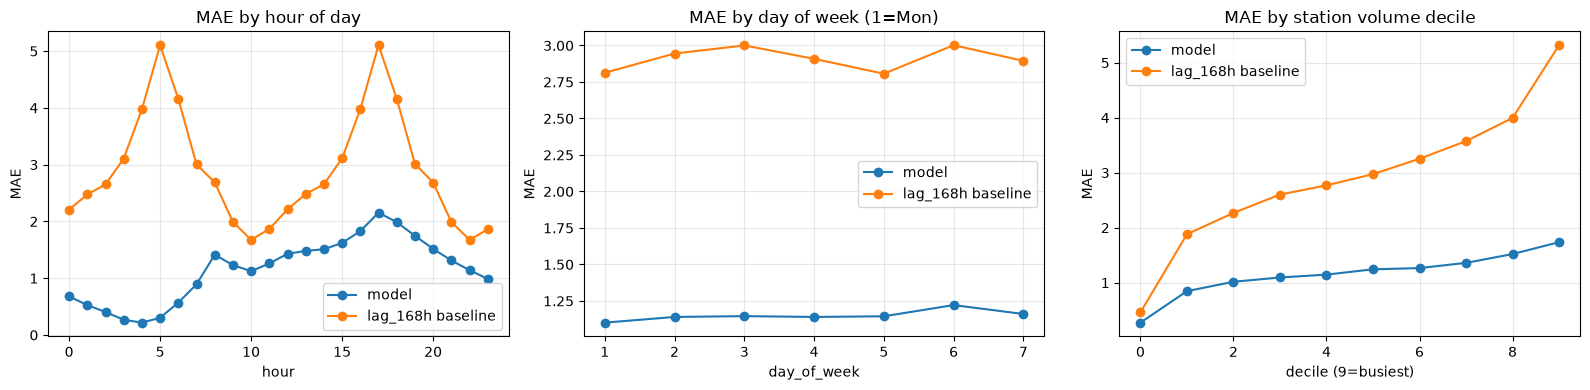

,abs_err,baseline_abs_err,trip_count
hour,,,
0,0.679,2.207,0.729
1,0.527,2.475,0.477
2,0.405,2.653,0.349
3,0.269,3.106,0.179
4,0.218,3.977,0.130
5,0.303,5.104,0.227
6,0.571,4.160,0.642
7,0.893,3.003,1.295
8,1.413,2.689,2.669


In [12]:
# Where does the error concentrate? Peak hours are what matter for rebalancing.
pred = np.clip(hgb.predict(X_test), 0, None)
err = test[["station_id", "hour", "day_of_week", TARGET]].copy()
err["pred"] = pred
err["abs_err"] = (err["pred"] - err[TARGET]).abs()
err["baseline_abs_err"] = (test["lag_168h"].clip(lower=0) - err[TARGET]).abs()

by_hour = err.groupby("hour")[["abs_err", "baseline_abs_err", TARGET]].mean()
by_dow = err.groupby("day_of_week")[["abs_err", "baseline_abs_err"]].mean()

# Station volume deciles: does the model hold up on the busy stations?
station_mean = err.groupby("station_id", observed=True)[TARGET].mean()
err["vol_decile"] = pd.qcut(
    err["station_id"].map(station_mean), 10, labels=False, duplicates="drop"
)
by_decile = err.groupby("vol_decile")[["abs_err", "baseline_abs_err", TARGET]].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
by_hour[["abs_err", "baseline_abs_err"]].plot(ax=axes[0], marker="o")
axes[0].set(title="MAE by hour of day", xlabel="hour", ylabel="MAE")
by_dow[["abs_err", "baseline_abs_err"]].plot(ax=axes[1], marker="o")
axes[1].set(title="MAE by day of week (1=Mon)", xlabel="day_of_week", ylabel="MAE")
by_decile[["abs_err", "baseline_abs_err"]].plot(ax=axes[2], marker="o")
axes[2].set(title="MAE by station volume decile", xlabel="decile (9=busiest)", ylabel="MAE")
for ax in axes:
    ax.legend(["model", "lag_168h baseline"])
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

by_hour.round(3)

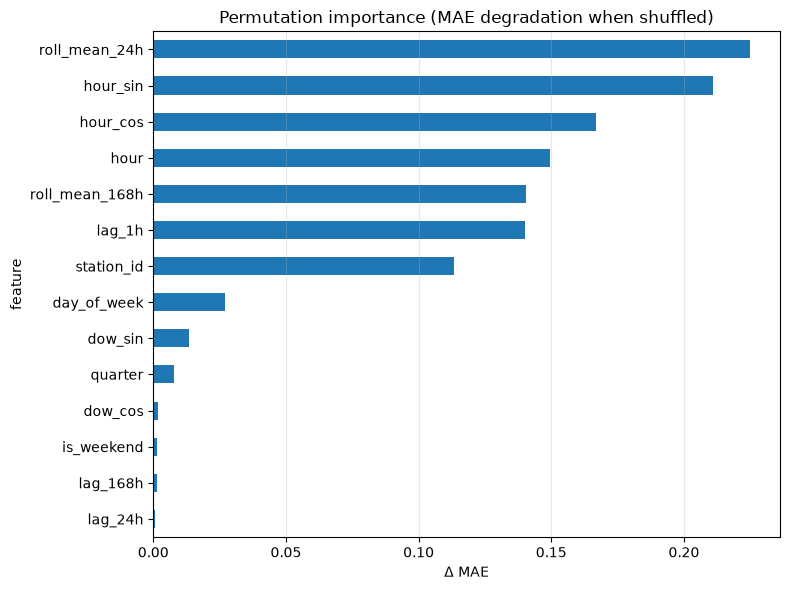

CPU times: total: 3.48 s
Wall time: 24.7 s


,feature,importance,std
0,roll_mean_24h,0.2250,0.0034
1,hour_sin,0.2110,0.0021
2,hour_cos,0.1668,0.0015
3,hour,0.1496,0.0012
4,roll_mean_168h,0.1406,0.0035
5,lag_1h,0.1401,0.0033
6,station_id,0.1132,0.0009
7,day_of_week,0.0272,0.0008
8,dow_sin,0.0134,0.0011
9,quarter,0.0077,0.0009


In [13]:
%%time
# Permutation importance on a subsample — full permutation over 1.3M rows is slow.
# A large lag_168h / roll_mean importance is expected; a large station_id importance
# would suggest the model is memorising levels rather than learning temporal structure.
sample = X_test.sample(n=min(50_000, len(X_test)), random_state=RANDOM_STATE)

imp = permutation_importance(
    hgb, sample, y_test.loc[sample.index],
    scoring="neg_mean_absolute_error",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)

importance = (
    pd.DataFrame({"feature": FEATURES,
                  "importance": imp.importances_mean,
                  "std": imp.importances_std})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

ax = importance.set_index("feature")["importance"].iloc[::-1].plot.barh(
    figsize=(8, 6), xerr=importance["std"].iloc[::-1])
ax.set(title="Permutation importance (MAE degradation when shuffled)", xlabel="Δ MAE")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

importance.round(4)

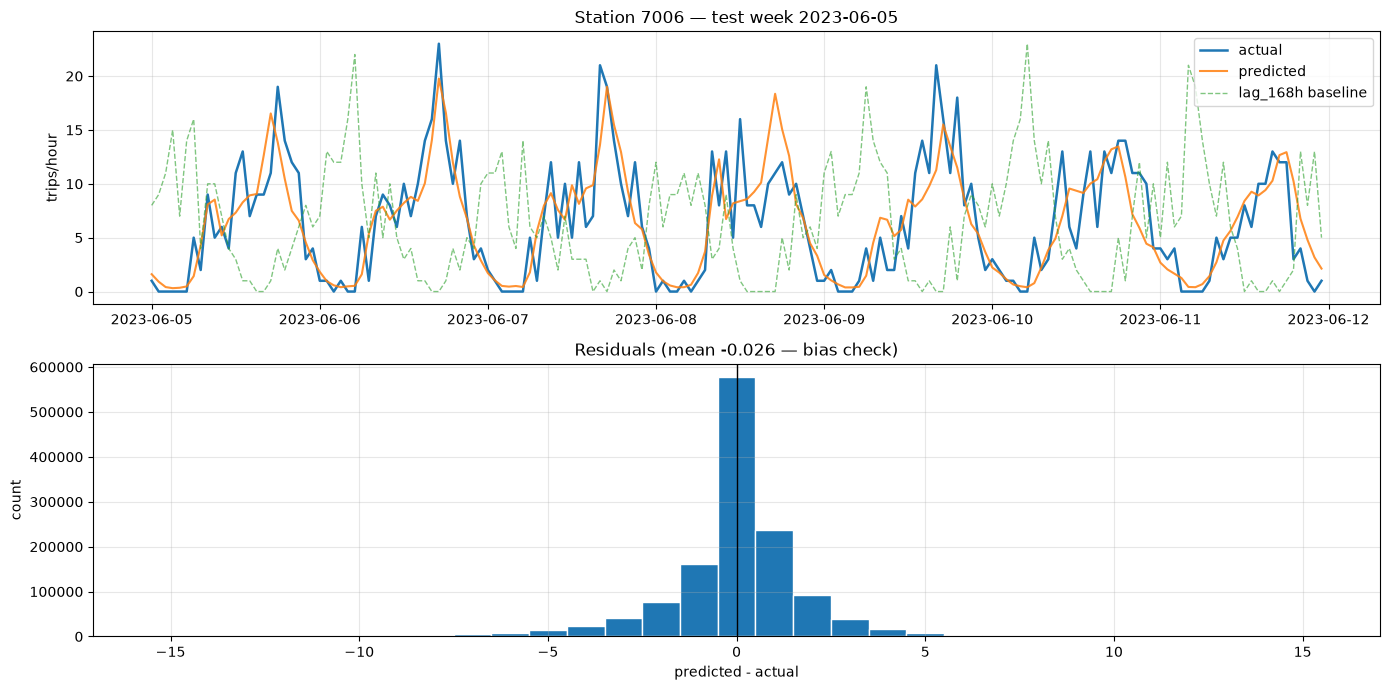

In [14]:
# Eyeball a busy station over one test week — does the daily shape track?
busiest = station_mean.idxmax()
week = test[(test["station_id"] == busiest)
            & (test["start_date"] >= "2023-06-05")
            & (test["start_date"] < "2023-06-12")].copy()
week["pred"] = np.clip(hgb.predict(week[FEATURES]), 0, None)
week["ts"] = week["start_date"] + pd.to_timedelta(week["hour"], unit="h")

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(week["ts"], week[TARGET], label="actual", lw=1.8)
axes[0].plot(week["ts"], week["pred"], label="predicted", lw=1.5, alpha=0.85)
axes[0].plot(week["ts"], week["lag_168h"], label="lag_168h baseline", lw=1, ls="--", alpha=0.6)
axes[0].set(title=f"Station {busiest} — test week 2023-06-05", ylabel="trips/hour")
axes[0].legend(); axes[0].grid(alpha=0.3)

residuals = err["pred"] - err[TARGET]
axes[1].hist(residuals, bins=np.arange(-15.5, 16.5), edgecolor="white")
axes[1].set(title=f"Residuals (mean {residuals.mean():+.3f} — bias check)",
            xlabel="predicted - actual", ylabel="count")
axes[1].axvline(0, color="k", lw=1)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8 — Persist

Model + metrics to `ml/artifacts/` (gitignored). The metrics file records the station
subset and feature list so a later scoring run can reproduce the exact input contract.

In [15]:
MODEL_PATH = ARTIFACTS / "model.joblib"
METRICS_PATH = ARTIFACTS / "metrics.json"

joblib.dump(hgb, MODEL_PATH)
joblib.dump(ridge, ARTIFACTS / "ridge.joblib")

metrics = {
    "target": TARGET,
    "features": FEATURES,
    "categorical": CATEGORICAL,
    "excluded": sorted(BANNED),
    "hyperparameters": BEST,
    "n_stations": N_STATIONS,
    "stations": [int(s) for s in TOP_STATIONS],
    "rows": {"train": int(len(train)), "test": int(len(test))},
    "train_period": [str(train["start_date"].min().date()), str(train["start_date"].max().date())],
    "test_period": [str(test["start_date"].min().date()), str(test["start_date"].max().date())],
    "results": leaderboard.reset_index().to_dict(orient="records"),
    "baseline_mae": float(BASELINE_MAE),
    "beats_baseline": bool(best_mae < BASELINE_MAE),
}
METRICS_PATH.write_text(json.dumps(metrics, indent=2))

print(f"model   {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1024**2:.1f} MB)")
print(f"metrics {METRICS_PATH}")

model   c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\ml\artifacts\model.joblib  (2.4 MB)
metrics c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\ml\artifacts\metrics.json


In [16]:
# Round-trip check: the reloaded model must reproduce the test MAE exactly.
reloaded = joblib.load(MODEL_PATH)
reloaded_mae = mean_absolute_error(y_test, np.clip(reloaded.predict(X_test), 0, None))
hgb_mae = next(r["MAE"] for r in results if r["model"] == "HistGradientBoosting")

assert np.isclose(reloaded_mae, hgb_mae), f"{reloaded_mae} != {hgb_mae}"
print(f"round-trip OK — reloaded MAE {reloaded_mae:.6f}")

round-trip OK — reloaded MAE 1.150725
